# GuitarNeXt - Music Genre Classification

In [ ]:
# Install dependencies
# !pip install librosa matplotlib scikit-learn torch torchvision tqdm pillow
print('Please install dependencies by uncommenting the line above.')

If running in a new environment, please install dependencies by uncommenting the pip line above.


In [ ]:
from pathlib import Path
import librosa
import numpy as np
from PIL import Image
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD
from torch.optim.lr_scheduler import MultiStepLR
from torchvision import transforms, datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,  precision_score, recall_score, f1_score

## Convert WAV → Mel-spectrogram PNGs
Notes:
- Uses 128 mel bands, log-scale, resized to 224×224 and saved as RGB PNG.
- Splits each class into 80/10/10.


In [ ]:
DATA_ROOT = Path('/content/drive/MyDrive/Data/genres_original')
OUT_ROOT = Path('/content/drive/MyDrive/Data/spectrograms')

SR = 22050
DURATION = 30.0
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
IMAGE_SIZE = 224
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

print('Data root exists?', DATA_ROOT.exists())
print('Output root will be:', OUT_ROOT)

Data root exists? True
Output root will be: /content/drive/MyDrive/Data/spectrograms


In [ ]:
def ensure_clean_dir(p: Path):
    if p.exists():
        pass
    p.mkdir(parents=True, exist_ok=True)

def wav_to_mel_image(wav_path, out_path, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, duration=DURATION, image_size=IMAGE_SIZE):
    y, sr = librosa.load(wav_path, sr=sr, duration=duration)

    expected_len = int(duration * sr)
    if y.shape[0] < expected_len:
        y = np.pad(y, (0, expected_len - y.shape[0]))

    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    # Normalize to 0-255
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-6)
    S_img = (S_norm * 255).astype(np.uint8)
    # Convert to PIL image and resize to 224 x 224
    img = Image.fromarray(S_img)
    img = img.resize((image_size, image_size), resample=Image.BILINEAR)
    img = img.convert('RGB')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_path)

def build_spectrogram_dataset(data_root=DATA_ROOT, out_root=OUT_ROOT, overwrite=False):
    classes = [d.name for d in sorted(data_root.iterdir()) if d.is_dir()]
    for cls in classes:
        wav_dir = data_root / cls
        files = sorted([p for p in wav_dir.iterdir() if p.suffix.lower() in ('.wav', '.au', '.mp3')])
        if len(files) == 0:
            print(f'No audio files found in {wav_dir}, skipping')
            continue
        # Shuffle
        random.seed(42)
        files = list(files)
        random.shuffle(files)
        n = len(files)
        n_train = int(n * TRAIN_RATIO)
        n_val = int(n * VAL_RATIO)
        train_files = files[:n_train]
        val_files = files[n_train:n_train + n_val]
        test_files = files[n_train + n_val:]

        for split, split_files in [('train', train_files), ('val', val_files), ('test', test_files)]:
            for p in tqdm(split_files, desc=f'{cls}:{split}', leave=False):
                outfile = out_root / split / cls / (p.stem + '.png')
                if outfile.exists() and not overwrite:
                    continue
                wav_to_mel_image(p, outfile)
    print('\nDone creating spectrograms in', out_root)

# Run conversion
build_spectrogram_dataset()

Found classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']



Done creating spectrograms in /content/drive/MyDrive/Data/spectrograms


## GuitarNeXt Implementation

In [ ]:
class PatchifyStem(nn.Module):
    def __init__(self, in_ch=3, out_ch=96):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=4, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class GuitarNeXtBlock(nn.Module):
    def __init__(self, channels, groups=1):
        super().__init__()
        self.gc7 = nn.Conv2d(channels, channels, kernel_size=7, padding=3, groups=groups, bias=False)
        self.conv1x1_a = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.conv1x1_c = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.maxpool5 = nn.MaxPool2d(kernel_size=5, stride=1, padding=2)
        self.avgpool5 = nn.AvgPool2d(kernel_size=5, stride=1, padding=2)
        self.gelu = nn.GELU()
        self.project = nn.Conv2d(4 * channels, channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(channels)
    def forward(self, x):
        y = self.gc7(x)
        a1 = self.gelu(self.conv1x1_a(y))
        a2 = self.gelu(self.maxpool5(y))
        branch1 = a1 * a2
        b1 = self.gelu(self.avgpool5(y))
        b2 = self.gelu(self.maxpool5(y))
        branch2 = b1 * b2
        c1 = self.gelu(self.conv1x1_c(y))
        c2 = self.gelu(self.avgpool5(y))
        branch3 = c1 * c2
        t_n2_1 = torch.cat([branch1, branch2], dim=1)
        t_n2_2 = torch.cat([branch1, branch3], dim=1)
        t_n3 = torch.cat([t_n2_1, t_n2_2], dim=1)
        out = self.project(t_n3)
        out = self.bn(out)
        out = out + x
        return out

class HybridDownsample(nn.Module):
    def __init__(self):
        super().__init__()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        a = self.maxpool(x)
        b = self.avgpool(x)
        out = torch.cat([a, b], dim=1)
        return out

class GuitarNeXt(nn.Module):
    def __init__(self, in_ch=3, num_classes=10):
        super().__init__()
        self.filters = [96, 192, 384, 768]
        self.stem = PatchifyStem(in_ch=in_ch, out_ch=self.filters[0])
        self.gn1 = GuitarNeXtBlock(self.filters[0])
        self.ds1 = HybridDownsample()
        self.gn2 = GuitarNeXtBlock(self.filters[1])
        self.ds2 = HybridDownsample()
        self.gn3 = GuitarNeXtBlock(self.filters[2])
        self.ds3 = HybridDownsample()
        self.gn4 = GuitarNeXtBlock(self.filters[3])
        self.post_conv = nn.Conv2d(1536, 1536, kernel_size=1, groups=1536, bias=False)
        self.post_gelu = nn.GELU()
        self.fc = nn.Linear(1536, num_classes)
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                if hasattr(m, 'weight') and m.weight is not None:
                    nn.init.ones_(m.weight)
                if hasattr(m, 'bias') and m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.stem(x)
        x = self.gn1(x)
        x = self.ds1(x)
        x = self.gn2(x)
        x = self.ds2(x)
        x = self.gn3(x)
        x = self.ds3(x)
        x = self.gn4(x)
        gap = F.adaptive_avg_pool2d(x, (1, 1))
        gmp = F.adaptive_max_pool2d(x, (1, 1))
        flat = torch.cat([gap, gmp], dim=1)
        fv = self.post_conv(flat)
        fv = self.post_gelu(fv)
        fv = fv.view(fv.size(0), -1)
        out = self.fc(fv)
        return out

## Training Loop and Utilities

In [ ]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_transforms(train=True, image_size=IMAGE_SIZE):
    if train:
        train_tf = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomApply([transforms.RandomRotation(15)], p=0.6),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        return train_tf
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

def train_one_epoch(model, dataloader, optimizer, device, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in tqdm(dataloader, desc='Train', leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, 100. * correct / total

def evaluate(model, dataloader, device, criterion, return_confusion=False, class_names=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Eval', leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Final aggregated metrics
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    # Convert lists → flat numpy arrays
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    # Compute extra metrics
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    if return_confusion:
        cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
        return {
            "loss": epoch_loss,
            "accuracy": epoch_acc,
            "precision_macro": precision,
            "recall_macro": recall,
            "f1_macro": f1,
            "confusion_matrix": cm
        }

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc
    }

## Dataloaders

In [ ]:
spec_root = OUT_ROOT
train_dir = spec_root / 'train'
val_dir = spec_root / 'val'
test_dir = spec_root / 'test'
assert train_dir.exists(), 'Train dir not found. Run spectrogram conversion first.'
train_tf = get_transforms(train=True)
val_tf = get_transforms(train=False)
train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds = datasets.ImageFolder(val_dir, transform=val_tf)
test_ds = datasets.ImageFolder(test_dir, transform=val_tf)

BATCH_SIZE = 32
NUM_WORKERS = 2
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## Instantiate model, loss, optimizer


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed_all(42)
model = GuitarNeXt(in_ch=3, num_classes=len(train_ds.classes)).to(device)
print('Model parameters (M):', sum(p.numel() for p in model.parameters()) / 1e6)
criterion = nn.CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-3)
scheduler = MultiStepLR(optimizer, milestones=[10, 20], gamma=0.1)

Model parameters (M): 43.109386


## Train

In [ ]:
EPOCHS = 25
best_val = 0.0
OUT_CKPT = Path('/content/drive/MyDrive/Data/checkpoints')
OUT_CKPT.mkdir(parents=True, exist_ok=True)
ckpt_path = OUT_CKPT / 'guitarnext_best.pth'
start_epoch = 1

train_losses = []
val_losses = []
train_accs = []
val_accs = []

if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt.get('epoch', 1)
    best_val = ckpt.get('best_val', 0.0)
    print("Resuming from epoch", start_epoch)
else:
    print("No checkpoint found, starting training from scratch.")

for epoch in range(start_epoch, EPOCHS + 1):
    print(f'Epoch {epoch}/{EPOCHS}')
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device, criterion)
    val_metrics = evaluate(model, val_loader, device, criterion)
    val_loss = val_metrics['loss']
    val_acc = val_metrics['accuracy']
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()
    print(f'Train loss: {train_loss:.4f}, acc: {train_acc:.2f}%')
    print(f'Val   loss: {val_loss:.4f}, acc: {val_acc:.2f}%')
    if val_acc > best_val:
        best_val = val_acc
        torch.save({'epoch': epoch + 1, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'class_names': train_ds.classes, 'best_val': best_val}, ckpt_path)
        print('Saved best checkpoint')


No checkpoint found, starting training from scratch.
Epoch 1/50


Train loss: 3.1854, acc: 18.27%
Val   loss: 2.4871, acc: 28.28%
Saved best checkpoint
Epoch 2/50


Train loss: 2.0666, acc: 31.16%
Val   loss: 1.8593, acc: 38.38%
Saved best checkpoint
Epoch 3/50


Train loss: 1.8584, acc: 36.17%
Val   loss: 1.8031, acc: 32.32%
Epoch 4/50


Train loss: 1.9171, acc: 34.04%
Val   loss: 1.7305, acc: 37.37%
Epoch 5/50


...

Train loss: 0.8316, acc: 71.46%
Val   loss: 1.0083, acc: 65.66%
Epoch 18/50


Train loss: 0.8241, acc: 73.97%
Val   loss: 1.0112, acc: 61.62%
Epoch 19/50


Train loss: 0.8263, acc: 71.84%
Val   loss: 1.0089, acc: 60.61%
Epoch 20/50


Train loss: 0.8150, acc: 72.22%
Val   loss: 1.0020, acc: 67.68%
Saved best checkpoint
Epoch 21/50


KeyboardInterrupt: 

## Evaluate on test set


Loaded checkpoint from /content/drive/MyDrive/Data/checkpoints/guitarnext_best.pth


Test Loss: 1.2059
Test Accuracy: 66.34%
Precision (macro): 0.6823
Recall (macro): 0.6627
F1-score (macro): 0.6581
[[8 0 0 0 0 0 0 0 1 1]
 [0 9 0 0 0 1 0 0 0 0]
 [0 0 7 0 0 2 0 0 0 1]
 [1 0 0 5 1 0 0 1 2 0]
 [0 1 0 0 4 0 1 1 3 0]
 [1 1 0 0 0 8 0 1 0 0]
 [0 0 0 0 0 0 9 0 0 1]
 [0 0 0 0 0 0 0 6 2 2]
 [0 0 0 1 0 0 1 0 8 0]
 [1 0 0 1 1 0 1 1 2 3]]


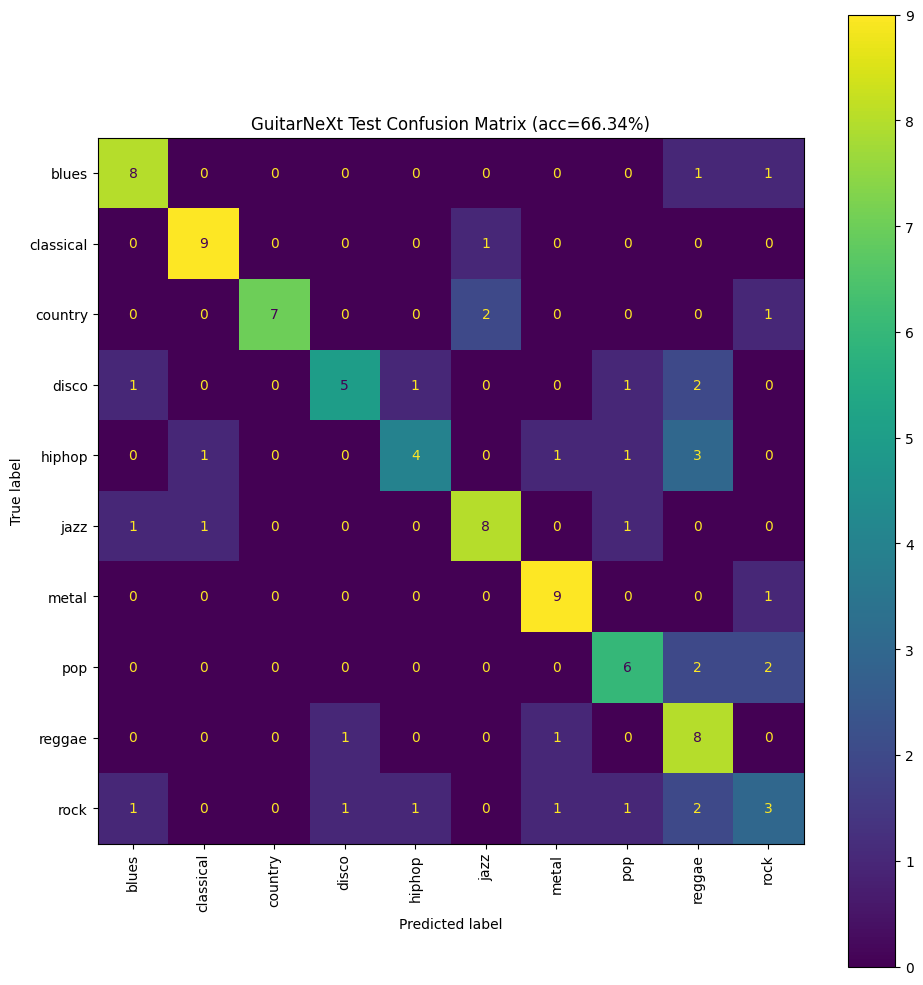

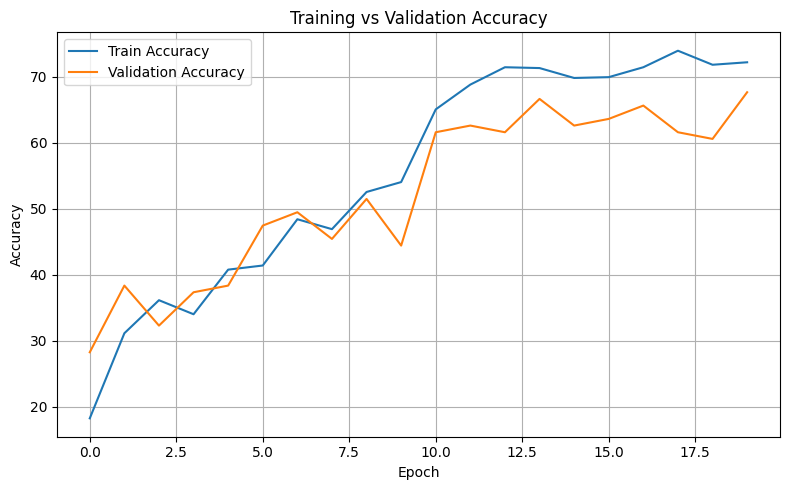

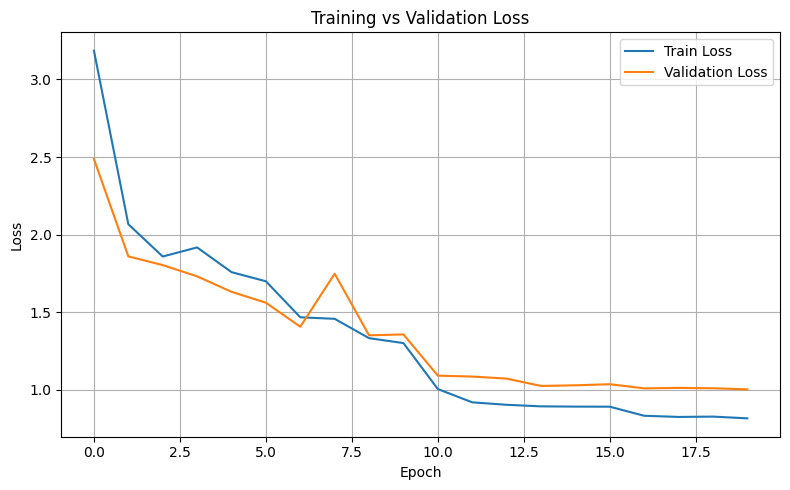

In [ ]:
ckpt_path = OUT_CKPT / 'guitarnext_best.pth'
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print('Loaded checkpoint from', ckpt_path)


metrics = evaluate(model, test_loader, device, criterion, return_confusion=True, class_names=train_ds.classes)
print(f"Test Loss: {metrics['loss']:.4f}")
print(f"Test Accuracy: {metrics['accuracy']:.2f}%")
print(f"Precision (macro): {metrics['precision_macro']:.4f}")
print(f"Recall (macro): {metrics['recall_macro']:.4f}")
print(f"F1-score (macro): {metrics['f1_macro']:.4f}")

fig, ax = plt.subplots(figsize=(10,10))
disp = ConfusionMatrixDisplay(confusion_matrix=metrics["confusion_matrix"], display_labels=train_ds.classes)
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title(f'GuitarNeXt Test Confusion Matrix (acc={metrics['accuracy']:.2f}%)')
plt.tight_layout()
fig.savefig('confusion_matrix.png')


plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir ~/.kaggle #create the .kaggle folder in your root directory
!echo '{"username":"eeerhs","key":"b9ce9cb87d477ee56f436ad91ce1065a"}' > ~/.kaggle/kaggle.json #write kaggle API credentials to kaggle.json
!chmod 600 ~/.kaggle/kaggle.json  # set permissions
!pip install kaggle #install the kaggle library

!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification -p /content/kaggle/